In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from torchsummary import summary
from sklearn.model_selection import train_test_split
from torch.autograd import Function
from torch.utils.data import Dataset
from scipy.optimize import curve_fit

In [ ]:
%pip install torchmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 869.5/869.5 kB 17.5 MB/s eta 0:00:00


In [ ]:
N = 20 #grandezza lato reticolo
temperatures = np.linspace(0.2, 5.0, 25) #valori temperature
n_samples = 100 # numero di campioni dopo burn in in ogni run
n_runs = 50 #numero di simulazioni indipendenti per ottenere statistiche affidabili
disorder_strengths = [0.5, 1.0, 1.5] #moduli del campo magnetico

Il codice ha lo scopo di analizzare le transizioni di fase del modello di Ising bidimensionale in presenza di un campo magnetico esterno. Sono dunque state sviluppate due reti neurali:

Una CNN:

*   Il modello è stato allenato utilizzando dati etichettati senza campo magnetico esterno, per i quali è nota la temperatura critica e il diagramma delle transizioni di fase.
Successivamente, il modello è stato impiegato per predire le etichette dei dati con campo magnetico esterno.

Una DANN (Domain-Adversarial Neural Network):


*   Il modello apprende le caratteristiche (feature) di entrambi i domini, sorgente e target: durante l'allenamento, cerca di confondere il classificatore di dominio, rendendo difficile determinare a quale dominio appartengano i dati.



L'intero processo è stato ripetuto per diversi valori del campo magnetico esterno.

La stima della temperatura critica è stata effettuata attraverso un fit con sigmoide, che ha permesso di ricavare un'incertezza statistica sulla stima.


DATA ANALYSIS

In [ ]:
# controlliamo se la GPU è disponibile e nel caso quale tipo di GPU
if torch.cuda.is_available():
  print('Numero di GPU disponibili: ',torch.cuda.device_count())
  for i in range(0,torch.cuda.device_count()):
    print(torch.cuda.get_device_name(i))

# se la GPU è disponibile setto device='cuda', altrimenti 'cpu
device = ('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Computation device: {device}\n")

Numero di GPU disponibili:  1
Tesla T4
Computation device: cuda



In [ ]:

data_source = np.loadtxt('data_source.txt', dtype=np.float32)
labels_source = np.loadtxt('labels_source.txt', dtype=np.int64)
data_target_0 = np.loadtxt('data_target_h_0.5.txt', dtype=np.float32)
data_target_1 = np.loadtxt('data_target_h_1.0.txt',dtype = np.float32)
data_target_2 = np.loadtxt('data_target_h_1.5.txt',dtype = np.float32)


print("Dimensioni data_source:", data_source.shape)
print("Dimensioni labels_source:", labels_source.shape)
print("Dimensioni data_target h = 0.5:", data_target_0.shape)
print("Dimensioni data_target h = 1.0:", data_target_1.shape)
print("Dimensioni data_target h = 1.5:", data_target_2.shape)

N = int(np.sqrt(data_source.shape[1])) #nel caso non si ha runnato tutto il codice, ricalcolo N reticolo

data_source = data_source.reshape(-1, 1, N, N) #devo fare reshape per numero di dati, numero di canali, grandezza immagine per reti convoluzionali
data_target_0 = data_target_0.reshape(-1, 1, N, N)
data_target_1 = data_target_1.reshape(-1, 1, N, N)
data_target_2 = data_target_2.reshape(-1, 1, N, N)

print("Nuova forma data_source:", data_source.shape)
print("Dimensioni data_target h = 0.5:", data_target_0.shape)
print("Dimensioni data_target h = 1.0:", data_target_1.shape)
print("Dimensioni data_target h = 1.5:", data_target_2.shape)



Dimensioni data_source: (125000, 400)
Dimensioni labels_source: (125000,)
Dimensioni data_target h = 0.5: (125000, 400)
Dimensioni data_target h = 1.0: (125000, 400)
Dimensioni data_target h = 1.5: (125000, 400)
Nuova forma data_source: (125000, 1, 20, 20)
Dimensioni data_target h = 0.5: (125000, 1, 20, 20)
Dimensioni data_target h = 1.0: (125000, 1, 20, 20)
Dimensioni data_target h = 1.5: (125000, 1, 20, 20)


In [ ]:
X_train, X_val, y_train, y_val = train_test_split(
    data_source, labels_source, test_size=0.25, shuffle=True, random_state=42)



# Stampa delle percentuali dei set
print('X_train percentage:', X_train.shape[0]*100/data_source.shape[0])
print('Y_train percentage:', y_train.shape[0]*100/data_source.shape[0])
print('X_val percentage:', X_val.shape[0]*100/data_source.shape[0])
print('Y_val percentage:', y_val.shape[0]*100/data_source.shape[0])


print('Training set shape:', X_train.shape)
print('Validation set shape:', X_val.shape)

# Conversione in tensori PyTorch
X_train_pt = torch.tensor(X_train, dtype=torch.float32)
y_train_pt = torch.tensor(y_train, dtype=torch.long)

X_val_pt = torch.tensor(X_val, dtype=torch.float32)
y_val_pt = torch.tensor(y_val, dtype=torch.long)

X_target_pt_0 = torch.tensor(data_target_0, dtype=torch.float32)
X_target_pt_1 = torch.tensor(data_target_1, dtype=torch.float32)
X_target_pt_2 = torch.tensor(data_target_2, dtype=torch.float32)


X_train percentage: 75.0
Y_train percentage: 75.0
X_val percentage: 25.0
Y_val percentage: 25.0
Training set shape: (93750, 1, 20, 20)
Validation set shape: (31250, 1, 20, 20)


dato che il dataloader del target mi restituisce una tupla di dimensione 1, devo muovermi in maniera diversa:

In [ ]:
class UnlabeledDataset(Dataset):
    def __init__(self, data):
        self.data = data
    def __len__(self):
        return len(self.data)
    def __getitem__(self, idx):
        return self.data[idx]

In [ ]:
batch = 128



ds_source_train = TensorDataset(X_train_pt, y_train_pt)
dl_source_train = DataLoader(ds_source_train, batch_size=batch, shuffle=True, num_workers=1, drop_last=True)

ds_source_val = TensorDataset(X_val_pt, y_val_pt)
dl_source_val = DataLoader(ds_source_val, batch_size=batch, shuffle=True, num_workers=1, drop_last=True)


target_dataset_0 = UnlabeledDataset(X_target_pt_0)
target_loader_0 = DataLoader(target_dataset_0, batch_size=batch, shuffle=True, num_workers=1, drop_last=True)

target_dataset_1 = UnlabeledDataset(X_target_pt_1)
target_loader_1 = DataLoader(target_dataset_1, batch_size=batch, shuffle=True, num_workers=1, drop_last=True)

target_dataset_2 = UnlabeledDataset(X_target_pt_2)
target_loader_2 = DataLoader(target_dataset_2, batch_size=batch, shuffle=True, num_workers=1, drop_last=True)

IMPLEMENTAZIONE CNN

In [ ]:
class CNN(nn.Module):
    def __init__(self, num_classes, N):
        super(CNN, self).__init__()

         # Definizione delle componenti convoluzionali e di pooling
        self.features = nn.Sequential(

            nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1),
            nn.MaxPool2d(kernel_size=2, stride=2),


            nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
        )

        # Calcolo della dimensione dell'input per il layer fully connected
        with torch.no_grad():

            dummy_input = torch.zeros(1, 1, N, N)
            dummy_output = self.features(dummy_input)
            self.fc_input_dim = dummy_output.view(1, -1).size(1)


        # Definizione dei layer fully connected
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(self.fc_input_dim, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes),
            nn.LogSoftmax(dim=1)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [ ]:
model = CNN(num_classes=2,N=N)
print(model)

from torchsummary import summary
if torch.cuda.is_available():
  summary(model.cuda(), input_size=(1,N,N))
else:
  summary(model, input_size=(1,N,N))

CNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): ReLU()
    (6): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=1600, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=2, bias=True)
    (4): LogSoftmax(dim=1)
  )
)
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 32, 20, 20]             320
              R

In [ ]:
loss = nn.NLLLoss()
#optimizer = optim.SGD(model.parameters(), lr = 1e-4,momentum = 0.9)
optimizer = optim.Adam(model.parameters(),lr = 1e-5)

from torchmetrics.classification import Accuracy

metric_fun = Accuracy(task = 'binary').to(device)

In [ ]:
def training(nn_model, optimizer, criterion, metric_fun, device, num_epochs, train_loader, vali_loader):

    hist_train_loss = []
    hist_vali_loss = []
    hist_train_acc = []
    hist_vali_acc = []
    best_val_accuracy = 0.0

    nn_model.to(device)  # Assicura che il modello sia sul dispositivo corretto

    for epoch in range(num_epochs):

        # Training phase
        nn_model.train()
        train_loss = 0.0
        total_train_samples = 0
        metric_fun.reset()

        for xb, yb in train_loader:
            xb = xb.to(device)
            yb = yb.to(device)
            batch_size = yb.size(0)
            total_train_samples += batch_size

            optimizer.zero_grad()
            yb_pred = nn_model(xb)
            loss = criterion(yb_pred, yb)
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * batch_size  # Accumula la perdita pesata per batch

            preds = yb_pred.argmax(dim=1)
            metric_fun.update(preds, yb)

        train_loss /= total_train_samples  # Perdita media per campione
        hist_train_loss.append(train_loss)
        train_accuracy = metric_fun.compute().item()
        hist_train_acc.append(train_accuracy)

        # Validation phase
        nn_model.eval()
        vali_loss = 0.0
        total_vali_samples = 0
        metric_fun.reset()

        with torch.no_grad():
            for xb, yb in vali_loader:
                xb = xb.to(device)
                yb = yb.to(device)
                batch_size = yb.size(0)
                total_vali_samples += batch_size

                yb_pred = nn_model(xb)
                loss = criterion(yb_pred, yb)
                vali_loss += loss.item() * batch_size
                preds = yb_pred.argmax(dim=1)
                metric_fun.update(preds, yb)

        vali_loss /= total_vali_samples
        hist_vali_loss.append(vali_loss)
        vali_accuracy = metric_fun.compute().item()
        hist_vali_acc.append(vali_accuracy)


        if vali_accuracy > best_val_accuracy:
            best_val_accuracy = vali_accuracy
            best_model_state = nn_model.state_dict()
            torch.save(best_model_state, 'best_model.pt')

        print(f'Epoch {epoch+1}/{num_epochs}: '
              f'train loss = {train_loss:.4f}, '
              f'vali loss = {vali_loss:.4f}, '
              f'train acc = {train_accuracy*100:.2f}%, '
              f'vali acc = {vali_accuracy*100:.2f}%')


    nn_model.load_state_dict(torch.load('best_model.pt'))

    return nn_model, hist_train_loss, hist_train_acc, hist_vali_loss, hist_vali_acc



In [ ]:
epochs = 50
model, hist_train_loss, hist_train_acc, hist_vali_loss, hist_vali_acc = training(
    model,
    optimizer,
    loss,
    metric_fun,
    device,
    epochs,
    dl_source_train,
    dl_source_val
)

Epoch 1/50: train loss = 0.1910, vali loss = 0.0433, train acc = 94.35%, vali acc = 98.32%
Epoch 2/50: train loss = 0.0440, vali loss = 0.0415, train acc = 98.16%, vali acc = 98.34%
Epoch 3/50: train loss = 0.0427, vali loss = 0.0425, train acc = 98.25%, vali acc = 98.27%
Epoch 4/50: train loss = 0.0421, vali loss = 0.0407, train acc = 98.22%, vali acc = 98.34%
Epoch 5/50: train loss = 0.0414, vali loss = 0.0402, train acc = 98.27%, vali acc = 98.35%
Epoch 6/50: train loss = 0.0407, vali loss = 0.0401, train acc = 98.33%, vali acc = 98.38%
Epoch 7/50: train loss = 0.0403, vali loss = 0.0401, train acc = 98.31%, vali acc = 98.34%
Epoch 8/50: train loss = 0.0399, vali loss = 0.0391, train acc = 98.33%, vali acc = 98.38%
Epoch 9/50: train loss = 0.0398, vali loss = 0.0397, train acc = 98.34%, vali acc = 98.38%
Epoch 10/50: train loss = 0.0394, vali loss = 0.0382, train acc = 98.39%, vali acc = 98.42%
Epoch 11/50: train loss = 0.0389, vali loss = 0.0379, train acc = 98.38%, vali acc = 98.4

<ipython-input-167-16770dba6e8d>:78: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  nn_model.load_state_dict(torch.load('best_model.pt'))


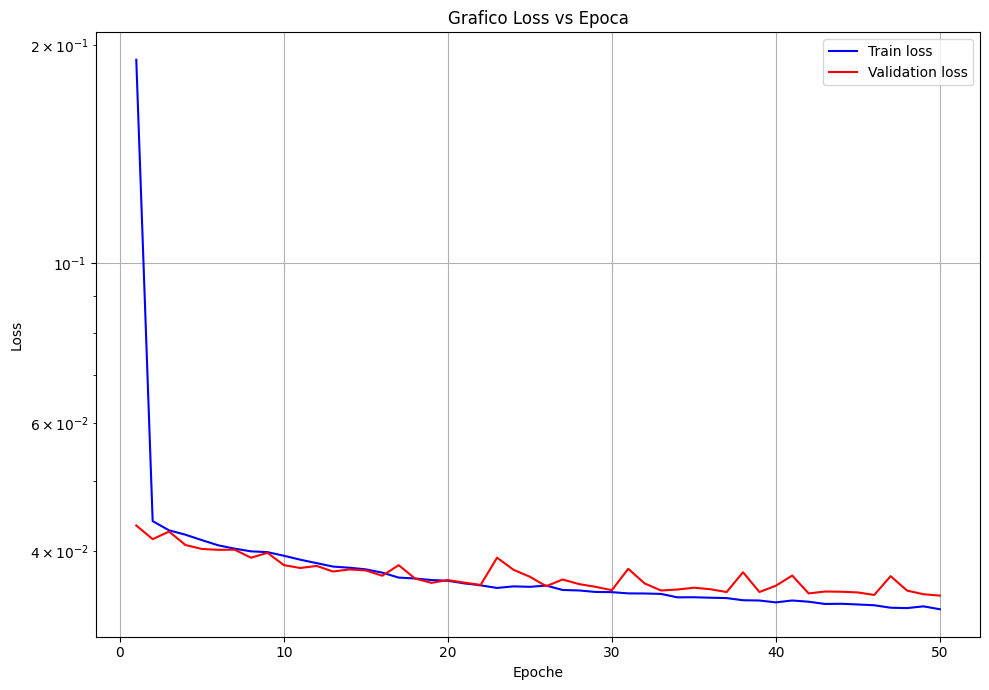

In [ ]:
# grafico loss vs epoca


plt.figure(figsize=(10, 7))
plt.title('Grafico Loss vs Epoca')
plt.plot(range(1,len(hist_train_loss)+1), hist_train_loss, color='blue', linestyle='-', label='Train loss ')
plt.plot(range(1,len(hist_vali_loss)+1), hist_vali_loss, color='red', linestyle='-', label='Validation loss')

plt.xlabel('Epoche')
plt.ylabel('Loss')
plt.yscale('log')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

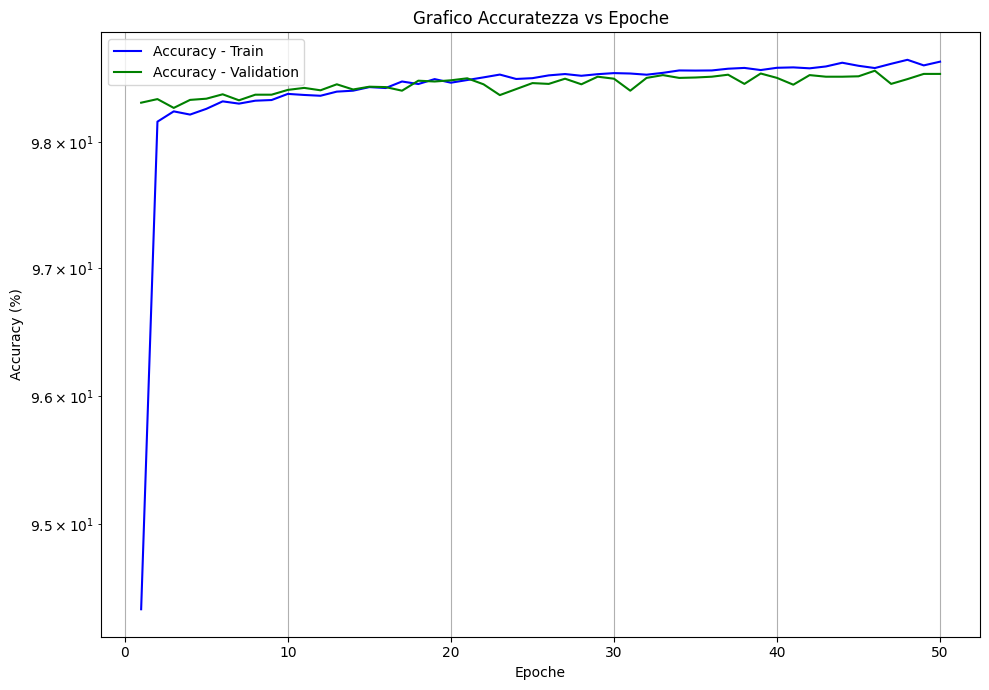

In [ ]:
# Grafico dell'accuratezza
plt.figure(figsize=(10, 7))
plt.title('Grafico Accuratezza vs Epoche')
plt.plot(range(1, len(hist_train_acc)+1), [acc * 100 for acc in hist_train_acc], color='blue', linestyle='-', label='Accuracy - Train')
plt.plot(range(1, len(hist_vali_acc)+1), [acc * 100 for acc in hist_vali_acc], color='green', linestyle='-', label='Accuracy - Validation')

plt.xlabel('Epoche')
plt.ylabel('Accuracy (%)')
plt.yscale('log')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
# Caricamento dei dati del dominio sorgente e target - importo di nuovo perchè mi serve l'ordine della temperatura
data_source = np.loadtxt('data_source.txt', dtype=np.float32)
labels_source = np.loadtxt('labels_source.txt', dtype=np.int64)
data_target_0 = np.loadtxt('data_target_h_0.5.txt', dtype=np.float32)
data_target_1 = np.loadtxt('data_target_h_1.0.txt',dtype = np.float32)
data_target_2 = np.loadtxt('data_target_h_1.5.txt',dtype = np.float32)

data_target_0 = data_target_0.reshape(-1, 1, N, N)
data_target_1 = data_target_1.reshape(-1, 1, N, N)
data_target_2 = data_target_2.reshape(-1, 1, N, N)


X_target_pt_0 = torch.tensor(data_target_0, dtype=torch.float32)
X_target_pt_1 = torch.tensor(data_target_1, dtype=torch.float32)
X_target_pt_2 = torch.tensor(data_target_2, dtype=torch.float32)

target_dataset_0 = TensorDataset(X_target_pt_0)
target_loader_inference_0 = DataLoader(target_dataset_0, batch_size=batch, shuffle=False, num_workers=1) #stavolta non faccio shuffle perchè mi serve l'ordine della temperatura

target_dataset_1 = TensorDataset(X_target_pt_1)
target_loader_inference_1 = DataLoader(target_dataset_1, batch_size=batch, shuffle=False, num_workers=1) #stavolta non faccio shuffle perchè mi serve l'ordine della temperatura

target_dataset_2 = TensorDataset(X_target_pt_2)
target_loader_inference_2 = DataLoader(target_dataset_2, batch_size=batch, shuffle=False, num_workers=1) #stavolta non faccio shuffle perchè mi serve l'ordine della temperatura




num_samples_per_temp = n_runs * n_samples

# Devo creare un array di indici ripetuti per costruire l'istogramma
temperatures_source = np.repeat(temperatures, num_samples_per_temp)
temperatures_target = np.repeat(temperatures, num_samples_per_temp)



In [ ]:
# Predizione delle etichette per il dominio target
model.eval()
predicted_labels_target_0 = []
predicted_labels_target_1 = []
predicted_labels_target_2 = []



with torch.no_grad():
    for data in target_loader_inference_0:
        data = data[0].to(device)
        class_pred = model(data)
        preds = class_pred.argmax(dim=1)
        predicted_labels_target_0.extend(preds.cpu().numpy())

    for data in target_loader_inference_1:
        data = data[0].to(device)
        class_pred = model(data)
        preds = class_pred.argmax(dim=1)
        predicted_labels_target_1.extend(preds.cpu().numpy())

    for data in target_loader_inference_2:
        data = data[0].to(device)
        class_pred = model(data)
        preds = class_pred.argmax(dim=1)
        predicted_labels_target_2.extend(preds.cpu().numpy())


predicted_labels_target_0 = np.array(predicted_labels_target_0)
predicted_labels_target_1 = np.array(predicted_labels_target_1)
predicted_labels_target_2 = np.array(predicted_labels_target_2)

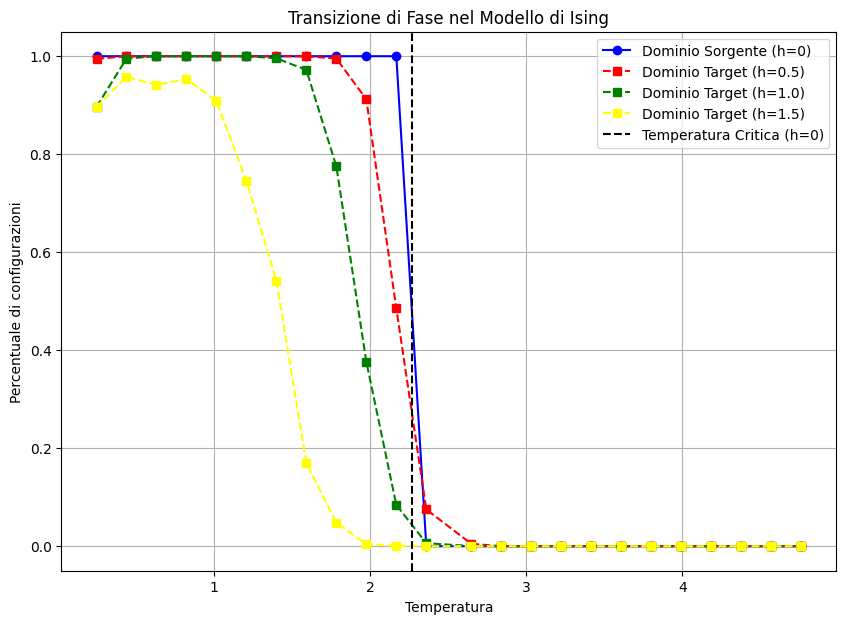

In [ ]:
def calculate_phase_fractions(temperatures, labels, num_bins=50):
    sorted_indices = np.argsort(temperatures)
    temperatures_sorted = temperatures[sorted_indices]
    labels_sorted = labels[sorted_indices]

    temperature_bins = np.linspace(
        temperatures_sorted.min(), temperatures_sorted.max(), num_bins + 1
    )

    fraction_phase1 = []
    bin_centers = []

    for i in range(num_bins):
        bin_indices = np.where(
            (temperatures_sorted >= temperature_bins[i]) &
            (temperatures_sorted < temperature_bins[i+1])
        )[0]
        if len(bin_indices) > 0:
            labels_in_bin = labels_sorted[bin_indices]
            fraction = np.mean(labels_in_bin)
            fraction_phase1.append(fraction)
            bin_center = (temperature_bins[i] + temperature_bins[i+1]) / 2
            bin_centers.append(bin_center)

    return bin_centers, fraction_phase1

bin_centers_source, fraction_phase1_source = calculate_phase_fractions(
    temperatures_source, labels_source
)

bin_centers_target_0, fraction_phase1_target_0 = calculate_phase_fractions(
    temperatures_target, predicted_labels_target_0
)

bin_centers_target_1, fraction_phase1_target_1 = calculate_phase_fractions(
    temperatures_target, predicted_labels_target_1
)


bin_centers_target_2, fraction_phase1_target_2 = calculate_phase_fractions(
    temperatures_target, predicted_labels_target_2
)




plt.figure(figsize=(10, 7))
plt.plot(
    bin_centers_source,
    fraction_phase1_source,
    'o-',
    color='b',
    label='Dominio Sorgente (h=0)'
)

plt.plot(
    bin_centers_target_0,
    fraction_phase1_target_0,
    's--',
    color='r',
    label='Dominio Target (h=0.5)'
)


plt.plot(
    bin_centers_target_1,
    fraction_phase1_target_1,
    's--',
    color='g',
    label='Dominio Target (h=1.0)'
)


plt.plot(
    bin_centers_target_2,
    fraction_phase1_target_2,
    's--',
    color='yellow',
    label='Dominio Target (h=1.5)'
)

Tc = 2.269
plt.axvline(x=Tc, color='k', linestyle='--', label='Temperatura Critica (h=0)')

plt.xlabel('Temperatura')
plt.ylabel('Percentuale di configurazioni')
plt.title('Transizione di Fase nel Modello di Ising')
plt.legend()
plt.grid(True)
plt.show()

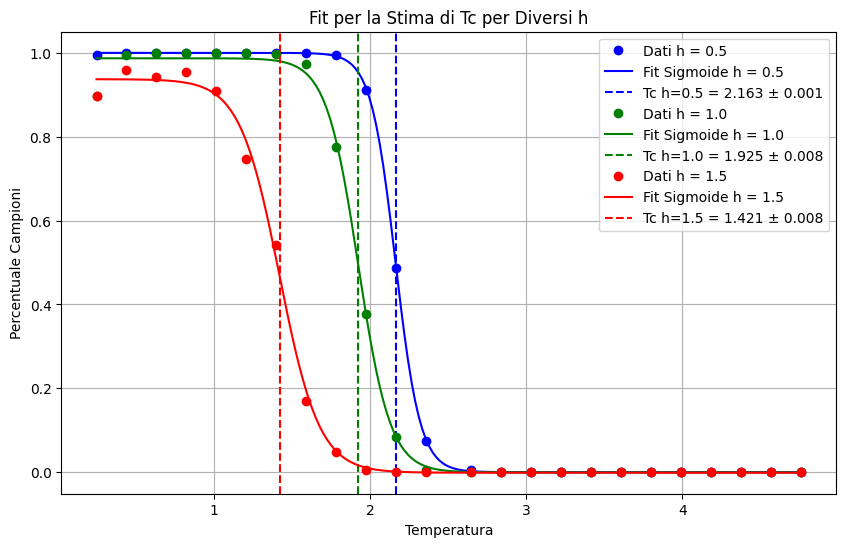

In [ ]:
def sigmoid(T, Tc, k, a, c):
    return a / (1 + np.exp(-k * (T - Tc))) + c

bin_centers_targets = [bin_centers_target_0, bin_centers_target_1, bin_centers_target_2]
fraction_phase1_targets = [fraction_phase1_target_0, fraction_phase1_target_1, fraction_phase1_target_2]

Tc_estimated = []
Tc_uncertainty = []
popt_list = []
pcov_list = []
T_fit_list = []
fraction_ordered_fit_list = []

for i in range(len(bin_centers_targets)):
    bin_centers = bin_centers_targets[i]
    fraction_phase1 = fraction_phase1_targets[i]


    initial_guesses = [np.median(bin_centers), 1.0, -1.0, 1.0]
    popt, pcov = curve_fit(sigmoid, bin_centers, fraction_phase1, p0=initial_guesses)

    Tc_estimated.append(popt[0])
    Tc_uncertainty.append(np.sqrt(np.diag(pcov))[0])
    popt_list.append(popt)
    pcov_list.append(pcov)


    T_fit = np.linspace(min(bin_centers), max(bin_centers), 200)
    fraction_ordered_fit = sigmoid(T_fit, *popt)
    T_fit_list.append(T_fit)
    fraction_ordered_fit_list.append(fraction_ordered_fit)

plt.figure(figsize=(10, 6))
colors = ['b', 'g', 'r']
h_values = [0.5, 1.0, 1.5]

for i in range(len(bin_centers_targets)):
    bin_centers = bin_centers_targets[i]
    fraction_phase1 = fraction_phase1_targets[i]
    T_fit = T_fit_list[i]
    fraction_ordered_fit = fraction_ordered_fit_list[i]
    Tc = Tc_estimated[i]
    Tc_err = Tc_uncertainty[i]
    h = h_values[i]

    plt.plot(bin_centers, fraction_phase1, 'o', color=colors[i % len(colors)], label=f'Dati h = {h}')
    plt.plot(T_fit, fraction_ordered_fit, '-', color=colors[i % len(colors)], label=f'Fit Sigmoide h = {h}')
    plt.axvline(Tc, color=colors[i % len(colors)], linestyle='--', label=f'Tc h={h} = {Tc:.3f} ± {Tc_err:.3f}')

plt.xlabel('Temperatura')
plt.ylabel('Percentuale Campioni')
plt.title('Fit per la Stima di Tc per Diversi h')
plt.legend()
plt.grid(True)
plt.show()

IMPLEMENTAZIONE DELLA DANN \\

"In order to suppress noisy signal from the domain classifier
at the early stages of the training procedure instead of fixing
the adaptation factor $\alpha$, we gradually change it from 0 to 1" [Unsupervised Domain Adaptation by Backpropagation - Yaroslav Ganin Victor Lempitsky]

In [ ]:
class ReverseLayerF(Function):

    @staticmethod
    def forward(ctx, x, alpha):


        ctx.alpha = alpha  # Salva il valore di alpha nel contesto per usarlo nel backward
        return x.view_as(x)  # Passa l'input così com'è

    @staticmethod
    def backward(ctx, grad_output):
        output = - ctx.alpha * grad_output  # Inverte il gradiente e lo scala per alpha
        return output, None



class DANN(nn.Module):
    def __init__(self, num_classes, N):
        super(DANN, self).__init__()
        # Feature extractor
        self.feature_extractor = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),



            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )
         # Calcolo della dimensione dell'input per il layer fully connected
        with torch.no_grad():
            dummy_input = torch.zeros(1, 1, N, N)
            dummy_output = self.feature_extractor(dummy_input)
            self.fc_input_dim = dummy_output.view(1, -1).size(1)

        # Layer fully connected condiviso
        self.shared_fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(self.fc_input_dim, 128),
            nn.ReLU(),
            nn.Dropout(p=0.5)
        )
        # Label predictor
        self.label_classifier = nn.Sequential(
            nn.Linear(128, 256),
            nn.ReLU(),
            nn.Dropout(p=0.5),
            nn.Linear(256, num_classes),
            nn.LogSoftmax(dim=1)
        )
        # Domain classifier
        self.domain_classifier = nn.Sequential(
            nn.Linear(128, 256),
            nn.ReLU(),
            nn.Dropout(p=0.5),
            nn.Linear(256, 2),
            nn.LogSoftmax(dim=1)
        )

    def forward(self, x, alpha=None):
      features = self.feature_extractor(x)
      features = self.shared_fc(features)
      class_pred = self.label_classifier(features)
      if self.training and alpha is not None:
          features_grl = ReverseLayerF.apply(features, alpha)
          domain_pred = self.domain_classifier(features_grl)
          return class_pred, domain_pred
      else:
          return class_pred, None

In [ ]:
model_0 = DANN(num_classes=2,N=N)
model_1 = DANN(num_classes=2,N=N)
model_2 = DANN(num_classes=2,N=N)
print(model_0)
print(model_1)
print(model_2)


model_0.to(device)
model_1.to(device)
model_2.to(device)

from torchsummary import summary
if torch.cuda.is_available():
  summary(model_0.cuda(), input_size=(1,N,N))
  summary(model_1.cuda(), input_size=(1,N,N))
  summary(model_2.cuda(), input_size=(1,N,N))
else:
  summary(model_0, input_size=(1,N,N))
  summary(model_1, input_size=(1,N,N))
  summary(model_2, input_size=(1,N,N))





models = [model_0,model_1,model_2]
targets = [target_loader_0,target_loader_1,target_loader_2]

DANN(
  (feature_extractor): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU()
    (7): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU()
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (shared_fc): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=1600, out_features=128, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.5, inplace=False)
  )
  (label_classifier): Sequential(
    (0): Linear(in_features=128, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.5, inplace=False)
    (3): Linear(in_features=256, out_features=2, bias=True)
    (4): LogSoftmax(di

In [ ]:
from torchmetrics.classification import Accuracy

metric_fun = Accuracy(task = 'binary').to(device)

In [ ]:
# Definizione delle loss function e dell'ottimizzatore. come loss uso NLL in quanto ho gi utilizzato una softmax nella mia rete
loss_class = nn.NLLLoss()
loss_domain = nn.NLLLoss()

optimizer_label = optim.SGD(model.parameters(),lr = 1e-4,momentum = 0.9)
#optimizer_label = optim.Adam(model.parameters(), lr = 1e-5)
optimizer_domain = optim.SGD(model.parameters(),lr = 1e-4,momentum = 0.9)



In [ ]:
def training(nn_model, optimizer_l,optimizer_d, criterion_class, criterion_domain, device, num_epochs, train_source, train_target, vali_source):
    import torchmetrics

    hist_loss_label = []
    hist_loss_domain = []
    hist_loss_label_vali = []
    hist_train_accuracy = []
    hist_val_accuracy = []
    hist_train_domain_accuracy = []

    best_val_accuracy = 0.0

    nn_model.to(device)


    label_accuracy = torchmetrics.Accuracy(task = 'binary').to(device)
    domain_accuracy = torchmetrics.Accuracy(task = 'binary').to(device)

    for epoch_index in range(num_epochs):
        nn_model.train()
        train_loss_label = 0.0
        train_loss_domain = 0.0
        total_samples_label = 0
        total_samples_domain = 0

        label_accuracy.reset()
        domain_accuracy.reset()

        num_batches = min(len(train_source), len(train_target))

        for batch_index, ((xs, ys), xt) in enumerate(zip(train_source, train_target)):
            optimizer_l.zero_grad()
            optimizer_d.zero_grad()

            p = float(epoch_index * num_batches + batch_index) / (num_epochs * num_batches)
            alpha = 2 / (1 + np.exp(-10 * p)) - 1

            # Sorgente
            xs = xs.to(device)
            ys = ys.to(device)
            batch_size_s = ys.size(0)
            total_samples_label += batch_size_s

            ys_domain = torch.zeros(batch_size_s, dtype=torch.long).to(device)
            ys_pred, ys_domain_pred = nn_model(xs, alpha)

            loss_s_label = criterion_class(ys_pred, ys)
            loss_s_domain = criterion_domain(ys_domain_pred, ys_domain)

            # Target
            xt = xt.to(device)
            batch_size_t = xt.size(0)
            total_samples_domain += batch_size_s + batch_size_t  # Sorgente + Target

            yt_domain = torch.ones(batch_size_t, dtype=torch.long).to(device)
            _, yt_domain_pred = nn_model(xt, alpha)

            loss_t_domain = criterion_domain(yt_domain_pred, yt_domain)

            # Backpropagation
            loss = loss_s_label + loss_s_domain + loss_t_domain
            loss.backward()
            optimizer_l.step()
            optimizer_d.step()


            train_loss_label += loss_s_label.item() * batch_size_s
            train_loss_domain += (loss_s_domain.item() * batch_size_s) + (loss_t_domain.item() * batch_size_t)

            # Aggiornamento delle metriche
            preds = ys_pred.argmax(dim=1)
            label_accuracy.update(preds, ys)

            domain_preds_source = ys_domain_pred.argmax(dim=1)
            domain_accuracy.update(domain_preds_source, ys_domain)
            domain_preds_target = yt_domain_pred.argmax(dim=1)
            domain_accuracy.update(domain_preds_target, yt_domain)


        train_loss_label /= total_samples_label
        train_loss_domain /= total_samples_domain

        train_accuracy = label_accuracy.compute().item()
        train_domain_accuracy = domain_accuracy.compute().item()

        # Validazione
        nn_model.eval()
        loss_vali = 0.0
        total_samples_vali = 0
        label_accuracy.reset()

        with torch.no_grad():
            for xs_val, ys_val in vali_source:
                xs_val = xs_val.to(device)
                ys_val = ys_val.to(device)
                batch_size_val = ys_val.size(0)
                total_samples_vali += batch_size_val

                label_pred, _ = nn_model(xs_val)
                loss = criterion_class(label_pred, ys_val)
                loss_vali += loss.item() * batch_size_val

                preds_val = label_pred.argmax(dim=1)
                label_accuracy.update(preds_val, ys_val)

        loss_vali /= total_samples_vali
        val_accuracy = label_accuracy.compute().item()

        # Salvo il miglior modello basato sull'accuratezza di validazione
        if val_accuracy > best_val_accuracy:
            best_val_accuracy = val_accuracy
            best_model_state = nn_model.state_dict()
            torch.save(best_model_state, 'best_model.pt')

        print(f'Epoch {epoch_index +1}/{num_epochs}: '
              f'class_loss = {train_loss_label:.4f}, '
              f'domain_loss = {train_loss_domain:.4f}, '
              f'validation label loss = {loss_vali:.4f}, '
              f'train accuracy = {train_accuracy*100:.2f}%, '
              f'train domain accuracy = {train_domain_accuracy*100:.2f}%, '
              f'val accuracy = {val_accuracy*100:.2f}%')

        hist_loss_label.append(train_loss_label)
        hist_loss_domain.append(train_loss_domain)
        hist_loss_label_vali.append(loss_vali)
        hist_train_accuracy.append(train_accuracy)
        hist_val_accuracy.append(val_accuracy)
        hist_train_domain_accuracy.append(train_domain_accuracy)



    nn_model.load_state_dict(torch.load('best_model.pt'))

    return nn_model, hist_loss_label, hist_loss_domain, hist_loss_label_vali, hist_train_accuracy, hist_val_accuracy, hist_train_domain_accuracy



In [ ]:
epochs = 50
model_histories = []


for i, (model, target_loader) in enumerate(zip(models, targets)):
    print(f"\nTraining model {i}...")


    optimizer_label = optim.Adam(model.label_classifier.parameters(), lr=1e-4)
    optimizer_domain = optim.SGD(model.parameters(),lr = 1e-4,momentum = 0.9)
    metric_fun = Accuracy(task = 'binary').to(device)
    loss_class = nn.NLLLoss()
    loss_domain = nn.NLLLoss()


    model, hist_loss_label, hist_loss_domain, hist_loss_label_vali, hist_train_accuracy, hist_val_accuracy, hist_train_domain_accuracy = training(
        model,
        optimizer_label,
        optimizer_domain,
        loss_class,
        loss_domain,
        device,
        epochs,
        dl_source_train,
        target_loader,
        dl_source_val
    )

    torch.save(model.state_dict(), f'model_{i}.pt')

    model_history = {
        'hist_loss_label': hist_loss_label,
        'hist_loss_domain': hist_loss_domain,
        'hist_loss_label_vali': hist_loss_label_vali,
        'hist_train_accuracy': hist_train_accuracy,
        'hist_val_accuracy': hist_val_accuracy,
        'hist_train_domain_accuracy': hist_train_domain_accuracy
    }
    model_histories.append(model_history)


Training model 0...
Epoch 1/50: class_loss = 0.4013, domain_loss = 0.6941, validation label loss = 0.0499, train accuracy = 77.33%, train domain accuracy = 49.93%, val accuracy = 98.16%
Epoch 2/50: class_loss = 0.0562, domain_loss = 0.6936, validation label loss = 0.0451, train accuracy = 97.90%, train domain accuracy = 49.88%, val accuracy = 98.26%
Epoch 3/50: class_loss = 0.0512, domain_loss = 0.6931, validation label loss = 0.0431, train accuracy = 98.07%, train domain accuracy = 50.66%, val accuracy = 98.30%
Epoch 4/50: class_loss = 0.0486, domain_loss = 0.6931, validation label loss = 0.0415, train accuracy = 98.16%, train domain accuracy = 50.60%, val accuracy = 98.36%
Epoch 5/50: class_loss = 0.0464, domain_loss = 0.6929, validation label loss = 0.0420, train accuracy = 98.22%, train domain accuracy = 50.98%, val accuracy = 98.32%
Epoch 6/50: class_loss = 0.0455, domain_loss = 0.6926, validation label loss = 0.0402, train accuracy = 98.22%, train domain accuracy = 51.24%, val a

<ipython-input-181-a386da448f3b>:132: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  nn_model.load_state_dict(torch.load('best_model.pt'))


Epoch 1/50: class_loss = 0.3895, domain_loss = 0.6935, validation label loss = 0.0569, train accuracy = 78.94%, train domain accuracy = 50.42%, val accuracy = 98.25%
Epoch 2/50: class_loss = 0.0574, domain_loss = 0.6918, validation label loss = 0.0440, train accuracy = 97.89%, train domain accuracy = 53.09%, val accuracy = 98.31%
Epoch 3/50: class_loss = 0.0499, domain_loss = 0.6907, validation label loss = 0.0430, train accuracy = 98.13%, train domain accuracy = 54.41%, val accuracy = 98.36%
Epoch 4/50: class_loss = 0.0480, domain_loss = 0.6903, validation label loss = 0.0442, train accuracy = 98.15%, train domain accuracy = 54.68%, val accuracy = 98.23%
Epoch 5/50: class_loss = 0.0471, domain_loss = 0.6900, validation label loss = 0.0414, train accuracy = 98.15%, train domain accuracy = 54.54%, val accuracy = 98.36%
Epoch 6/50: class_loss = 0.0450, domain_loss = 0.6899, validation label loss = 0.0413, train accuracy = 98.23%, train domain accuracy = 54.12%, val accuracy = 98.37%
Epoc

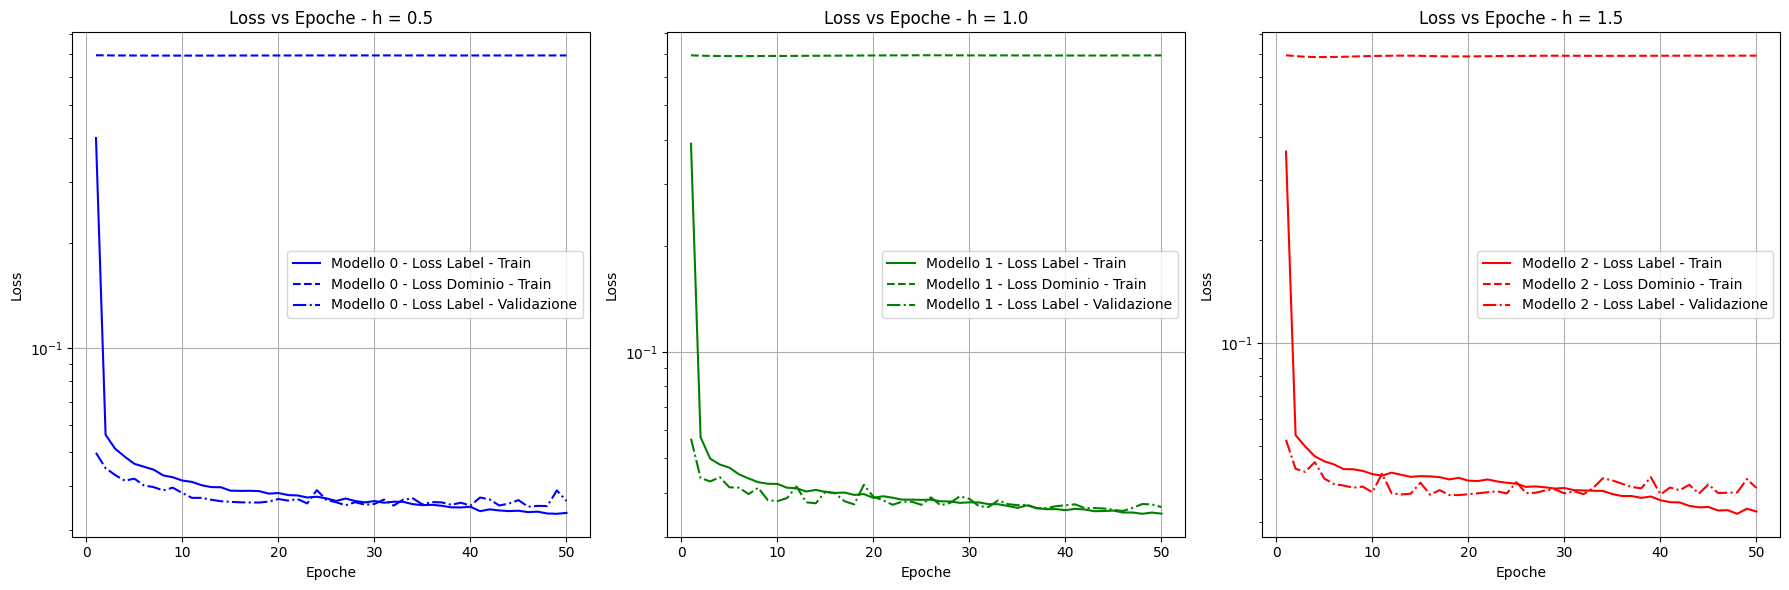

In [ ]:
# grafico loss vs epoca
colors = ['blue', 'green', 'red', 'cyan', 'magenta', 'orange', 'purple']
linestyles = ['-', '--', '-.', ':']

num_models = len(model_histories)
fig, axes = plt.subplots(1, num_models, figsize=(18, 6))

# Se hai solo un modello, axes potrebbe non essere un array. Assicuriamoci che sia iterabile.
if num_models == 1:
    axes = [axes]

for i, (ax, history) in enumerate(zip(axes, model_histories)):
    epochs = range(1, len(history['hist_loss_label']) + 1)

    color = colors[i % len(colors)]
    linestyle_label = linestyles[0]
    linestyle_domain = linestyles[1]
    linestyle_val = linestyles[2]

    ax.plot(epochs, history['hist_loss_label'], color=color, linestyle=linestyle_label,
            label=f'Modello {i} - Loss Label - Train')
    ax.plot(epochs, history['hist_loss_domain'], color=color, linestyle=linestyle_domain,
            label=f'Modello {i} - Loss Dominio - Train')
    ax.plot(epochs, history['hist_loss_label_vali'], color=color, linestyle=linestyle_val,
            label=f'Modello {i} - Loss Label - Validazione')

    ax.set_xlabel('Epoche')
    ax.set_ylabel('Loss')
    ax.set_yscale('log')
    ax.set_title(f'Loss vs Epoche - h = {i / 2 + 0.5}')
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.show()

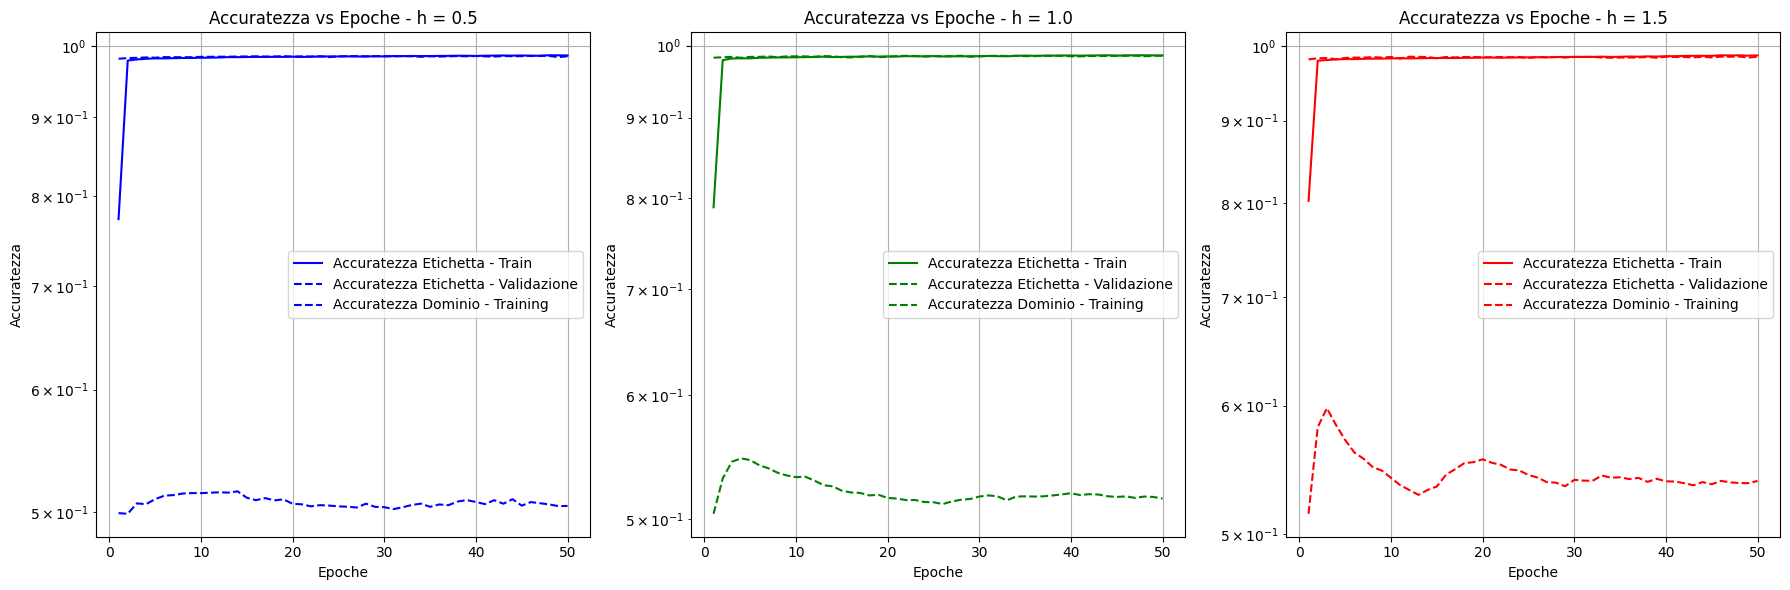

In [ ]:
# Grafico dell'accuratezza

colors = ['blue', 'green', 'red', 'cyan', 'magenta', 'orange', 'purple']
linestyles = ['-', '--', '-.']

num_models = len(model_histories)
fig, axes = plt.subplots(1, num_models, figsize=(18, 6))

# Assicurarsi che 'axes' sia iterabile
if num_models == 1:
    axes = [axes]

for i, (ax, history) in enumerate(zip(axes, model_histories)):
    epochs = range(1, len(history['hist_train_accuracy']) + 1)

    color = colors[i % len(colors)]
    linestyle_train = linestyles[0]
    linestyle_val = linestyles[1]
    linestyle_domain = linestyles[2]

    ax.plot(epochs, history['hist_train_accuracy'], color=color, linestyle=linestyle_train,
            label='Accuratezza Etichetta - Train')
    ax.plot(epochs, history['hist_val_accuracy'], color=color, linestyle=linestyle_val,
            label='Accuratezza Etichetta - Validazione')
    ax.plot(epochs, history['hist_train_domain_accuracy'], color=color, linestyle=linestyle_val,
            label='Accuratezza Dominio - Training')

    ax.set_xlabel('Epoche')
    ax.set_ylabel('Accuratezza')
    ax.set_yscale('log')
    ax.set_title(f'Accuratezza vs Epoche - h = {i / 2 + 0.5}')
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.show()

GRAFICI DELLA TRANSIZIONE DI FASE

In [ ]:
# Caricamento dei dati del dominio sorgente e target - importo di nuovo perchè mi serve l'ordine della temperatura
data_source = np.loadtxt('data_source.txt', dtype=np.float32)
labels_source = np.loadtxt('labels_source.txt', dtype=np.int64)
data_target_0 = np.loadtxt('data_target_h_0.5.txt', dtype=np.float32)
data_target_1 = np.loadtxt('data_target_h_1.0.txt',dtype = np.float32)
data_target_2 = np.loadtxt('data_target_h_1.5.txt',dtype = np.float32)

data_target_0 = data_target_0.reshape(-1, 1, N, N)
data_target_1 = data_target_1.reshape(-1, 1, N, N)
data_target_2 = data_target_2.reshape(-1, 1, N, N)


X_target_pt_0 = torch.tensor(data_target_0, dtype=torch.float32)
X_target_pt_1 = torch.tensor(data_target_1, dtype=torch.float32)
X_target_pt_2 = torch.tensor(data_target_2, dtype=torch.float32)

target_dataset_0 = TensorDataset(X_target_pt_0)
target_loader_inference_0 = DataLoader(target_dataset_0, batch_size=batch, shuffle=False, num_workers=1) #stavolta non faccio shuffle perchè mi serve l'ordine della temperatura

target_dataset_1 = TensorDataset(X_target_pt_1)
target_loader_inference_1 = DataLoader(target_dataset_1, batch_size=batch, shuffle=False, num_workers=1) #stavolta non faccio shuffle perchè mi serve l'ordine della temperatura

target_dataset_2 = TensorDataset(X_target_pt_2)
target_loader_inference_2 = DataLoader(target_dataset_2, batch_size=batch, shuffle=False, num_workers=1) #stavolta non faccio shuffle perchè mi serve l'ordine della temperatura




num_samples_per_temp = n_runs * n_samples

# Devo creare un array di indici ripetuti per costruire l'istogramma
temperatures_source = np.repeat(temperatures, num_samples_per_temp)
temperatures_target = np.repeat(temperatures, num_samples_per_temp)


target_loaders_inference = [target_loader_inference_0,target_loader_inference_1,target_loader_inference_2]


In [ ]:
# Predizione delle etichette per il dominio target

predicted_labels_targets = []

for i, (model, target_loader) in enumerate(zip(models, target_loaders_inference)):
    print(f"\nValutazione del modello {i}...")
    model.eval()
    predicted_labels = []
    with torch.no_grad():
        for data in target_loader:
            inputs = data[0].to(device)
            class_pred, _ = model(inputs)
            preds = class_pred.argmax(dim=1)
            predicted_labels.extend(preds.cpu().numpy())
    predicted_labels = np.array(predicted_labels)
    predicted_labels_targets.append(predicted_labels)





Valutazione del modello 0...

Valutazione del modello 1...

Valutazione del modello 2...


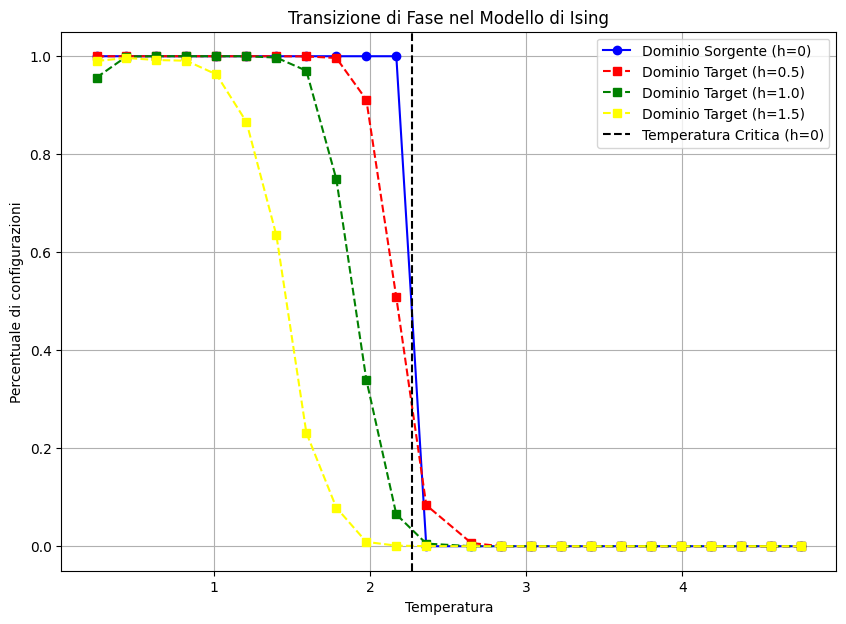

In [ ]:
bin_centers_source, fraction_phase1_source = calculate_phase_fractions(
    temperatures_source, labels_source
)

bin_centers_target_0, fraction_phase1_target_0 = calculate_phase_fractions(
    temperatures_target, predicted_labels_targets[0]
)

bin_centers_target_1, fraction_phase1_target_1 = calculate_phase_fractions(
    temperatures_target, predicted_labels_targets[1]
)


bin_centers_target_2, fraction_phase1_target_2 = calculate_phase_fractions(
    temperatures_target, predicted_labels_targets[2]
)



plt.figure(figsize=(10, 7))
plt.plot(
    bin_centers_source,
    fraction_phase1_source,
    'o-',
    color='b',
    label='Dominio Sorgente (h=0)'
)

plt.plot(
    bin_centers_target_0,
    fraction_phase1_target_0,
    's--',
    color='r',
    label='Dominio Target (h=0.5)'
)


plt.plot(
    bin_centers_target_1,
    fraction_phase1_target_1,
    's--',
    color='g',
    label='Dominio Target (h=1.0)'
)


plt.plot(
    bin_centers_target_2,
    fraction_phase1_target_2,
    's--',
    color='yellow',
    label='Dominio Target (h=1.5)'
)

Tc = 2.269
plt.axvline(x=Tc, color='k', linestyle='--', label='Temperatura Critica (h=0)')

plt.xlabel('Temperatura')
plt.ylabel('Percentuale di configurazioni')
plt.title('Transizione di Fase nel Modello di Ising')
plt.legend()
plt.grid(True)
plt.show()

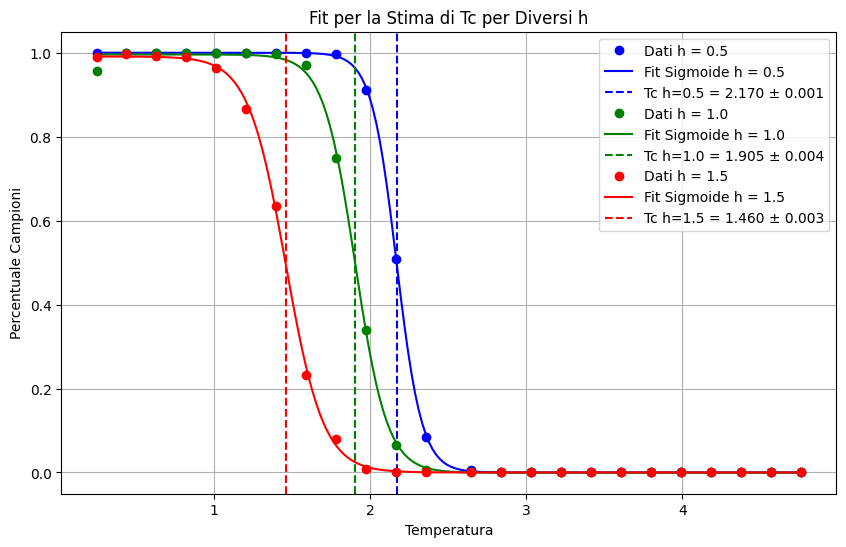

In [ ]:
def sigmoid(T, Tc, k, a, c):
    return a / (1 + np.exp(-k * (T - Tc))) + c

bin_centers_targets = [bin_centers_target_0, bin_centers_target_1, bin_centers_target_2]
fraction_phase1_targets = [fraction_phase1_target_0, fraction_phase1_target_1, fraction_phase1_target_2]

Tc_estimated = []
Tc_uncertainty = []
popt_list = []
pcov_list = []
T_fit_list = []
fraction_ordered_fit_list = []

for i in range(len(bin_centers_targets)):
    bin_centers = bin_centers_targets[i]
    fraction_phase1 = fraction_phase1_targets[i]


    initial_guesses = [np.median(bin_centers), 1.0, -1.0, 1.0]
    popt, pcov = curve_fit(sigmoid, bin_centers, fraction_phase1, p0=initial_guesses)

    Tc_estimated.append(popt[0])
    Tc_uncertainty.append(np.sqrt(np.diag(pcov))[0])
    popt_list.append(popt)
    pcov_list.append(pcov)


    T_fit = np.linspace(min(bin_centers), max(bin_centers), 200)
    fraction_ordered_fit = sigmoid(T_fit, *popt)
    T_fit_list.append(T_fit)
    fraction_ordered_fit_list.append(fraction_ordered_fit)

plt.figure(figsize=(10, 6))
colors = ['b', 'g', 'r']
h_values = [0.5, 1.0, 1.5]

for i in range(len(bin_centers_targets)):
    bin_centers = bin_centers_targets[i]
    fraction_phase1 = fraction_phase1_targets[i]
    T_fit = T_fit_list[i]
    fraction_ordered_fit = fraction_ordered_fit_list[i]
    Tc = Tc_estimated[i]
    Tc_err = Tc_uncertainty[i]
    h = h_values[i]

    plt.plot(bin_centers, fraction_phase1, 'o', color=colors[i % len(colors)], label=f'Dati h = {h}')
    plt.plot(T_fit, fraction_ordered_fit, '-', color=colors[i % len(colors)], label=f'Fit Sigmoide h = {h}')
    plt.axvline(Tc, color=colors[i % len(colors)], linestyle='--', label=f'Tc h={h} = {Tc:.3f} ± {Tc_err:.3f}')

plt.xlabel('Temperatura')
plt.ylabel('Percentuale Campioni')
plt.title('Fit per la Stima di Tc per Diversi h')
plt.legend()
plt.grid(True)
plt.show()

VERIFICA DELLA PRESENZA DI UNA TRANSIZIONE DI FASE

# conf. ordinate:  50000
# conf. critiche:  10000
# conf. disordinate:  60000


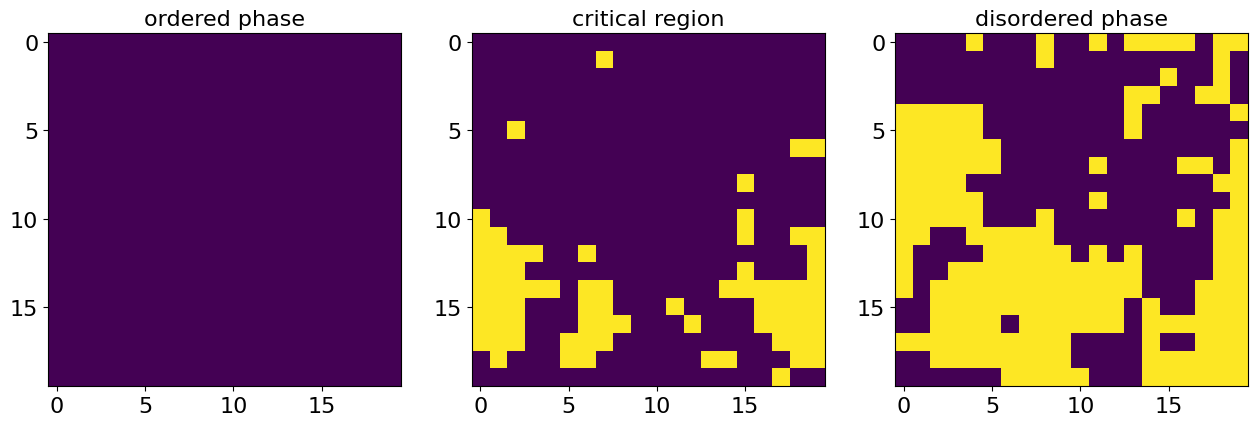

In [ ]:
source_2d = data_source.reshape(-1,N,N)


temperatures_source = np.repeat(temperatures, n_runs * n_samples)

labels = np.zeros(shape = temperatures_source.shape)


#per le condizioni senza campo magnetico
ordinato = (temperatures_source < 2)
critico = ((temperatures_source >= 2) & (temperatures_source <= 2.5))
disordinato = (temperatures_source > 2.5)


labels[ordinato] = 0
labels[critico] = 1
labels[disordinato] = 2

print('# conf. ordinate: ', labels[ordinato].shape[0])
print('# conf. critiche: ', labels[critico].shape[0])
print('# conf. disordinate: ', labels[disordinato].shape[0])

conf = 124

fig, axarr = plt.subplots(nrows=1, ncols=3)

axarr[0].imshow((source_2d[ordinato])[conf])
axarr[0].set_title('ordered phase',fontsize=16)
axarr[0].tick_params(labelsize=16)

axarr[1].imshow((source_2d[critico])[conf])
axarr[1].set_title('critical region',fontsize=16)
axarr[1].tick_params(labelsize=16)

im=axarr[2].imshow((source_2d[disordinato])[conf])
axarr[2].set_title('disordered phase',fontsize=16)
axarr[2].tick_params(labelsize=16)

fig.subplots_adjust(right=2.0)

plt.show()

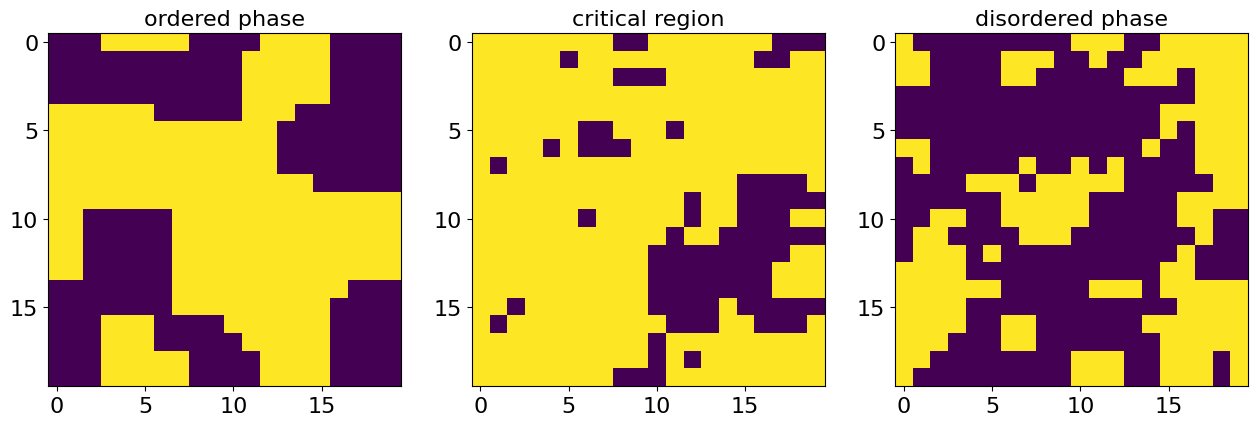

In [ ]:
target_0_2d = data_target_0.reshape(-1,N,N)
target_1_2d = data_target_1.reshape(-1,N,N)
target_2_2d = data_target_2.reshape(-1,N,N)

temperatures_source = np.repeat(temperatures, n_runs * n_samples)

labels_0 = np.zeros(shape = temperatures_source.shape)
labels_1 = np.zeros(shape = temperatures_source.shape)
labels_2 = np.zeros(shape = temperatures_source.shape)

#per le condizioni con campo magnetico
ordinato_0 = (temperatures_source < 2)
critico_0 = ((temperatures_source >= 2) & (temperatures_source <= 2.5))
disordinato_0 = (temperatures_source > 2.5)


ordinato_1 = (temperatures_source < 1.5)
critico_1 = ((temperatures_source >= 1.5) & (temperatures_source <= 2.2))
disordinato_1 = (temperatures_source > 2.2)

ordinato_2 = (temperatures_source < 1.2)
critico_2 = ((temperatures_source >= 1.2) & (temperatures_source <= 1.6))
disordinato_2 = (temperatures_source > 1.6)



labels_0[ordinato_0] = 0
labels_1[ordinato_1] = 0
labels_2[ordinato_2] = 0


labels_0[critico_0] = 1
labels_1[critico_1] = 1
labels_2[critico_2] = 1


labels_0[disordinato_0] = 2
labels_1[disordinato_1] = 2
labels_2[disordinato_2] = 2


conf = 366

fig, axarr = plt.subplots(nrows=1, ncols=3)

axarr[0].imshow((target_0_2d[ordinato_0])[conf])
axarr[0].set_title('ordered phase',fontsize=16)
axarr[0].tick_params(labelsize=16)

axarr[1].imshow((target_0_2d[critico_0])[conf])
axarr[1].set_title('critical region',fontsize=16)
axarr[1].tick_params(labelsize=16)

im=axarr[2].imshow((target_0_2d[disordinato_0])[conf])
axarr[2].set_title('disordered phase',fontsize=16)
axarr[2].tick_params(labelsize=16)

fig.subplots_adjust(right=2.0)

plt.show()

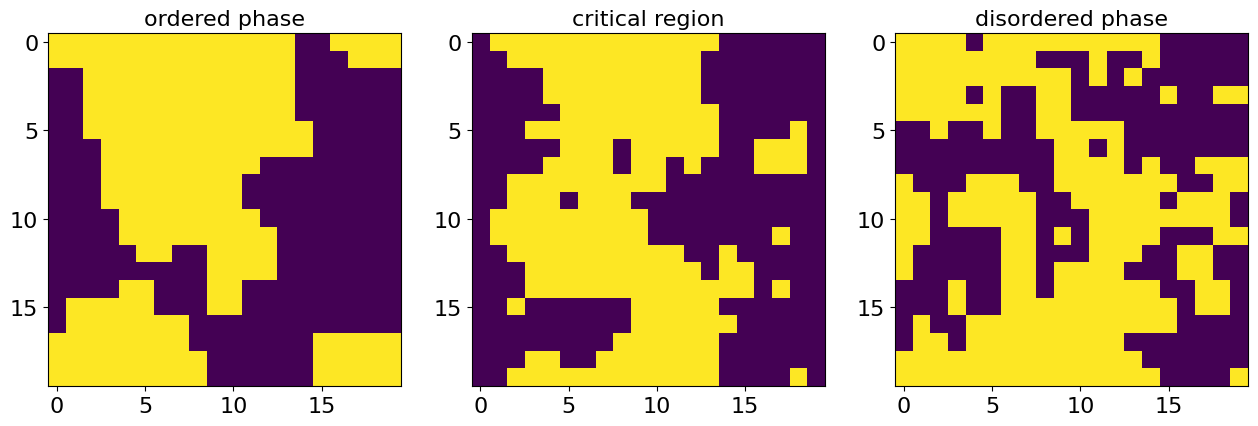

In [ ]:
conf = 42



fig, axarr = plt.subplots(nrows=1, ncols=3)

axarr[0].imshow((target_1_2d[ordinato_1])[conf])
axarr[0].set_title('ordered phase',fontsize=16)
axarr[0].tick_params(labelsize=16)

axarr[1].imshow((target_1_2d[critico_1])[conf])
axarr[1].set_title('critical region',fontsize=16)
axarr[1].tick_params(labelsize=16)

im=axarr[2].imshow((target_1_2d[disordinato_1])[conf])
axarr[2].set_title('disordered phase',fontsize=16)
axarr[2].tick_params(labelsize=16)

fig.subplots_adjust(right=2.0)

plt.show()

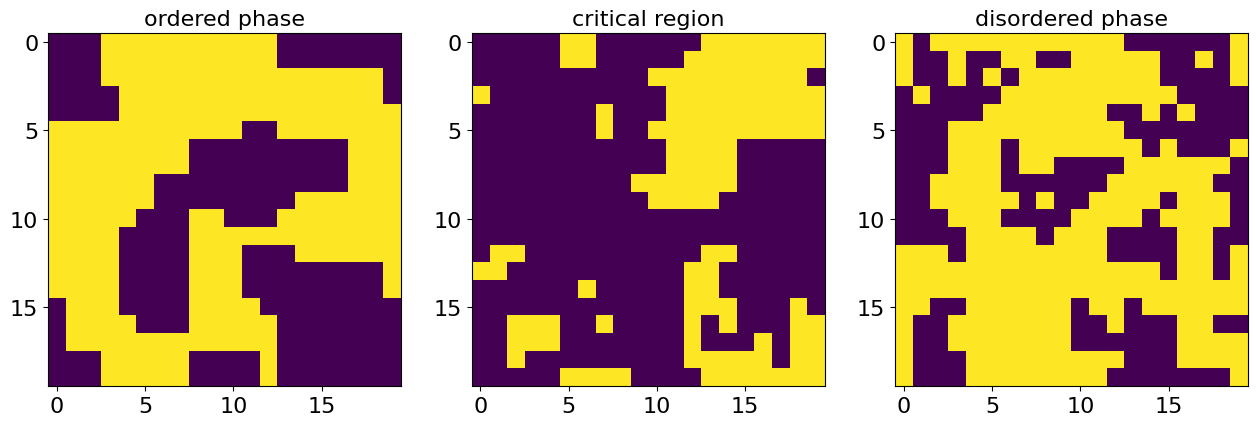

In [ ]:
conf = 124



fig, axarr = plt.subplots(nrows=1, ncols=3)

axarr[0].imshow((target_2_2d[ordinato_2])[conf])
axarr[0].set_title('ordered phase',fontsize=16)
axarr[0].tick_params(labelsize=16)

axarr[1].imshow((target_2_2d[critico_2])[conf])
axarr[1].set_title('critical region',fontsize=16)
axarr[1].tick_params(labelsize=16)

im=axarr[2].imshow((target_2_2d[disordinato_2])[conf])
axarr[2].set_title('disordered phase',fontsize=16)
axarr[2].tick_params(labelsize=16)

fig.subplots_adjust(right=2.0)

plt.show()